# 🔰 **Overview**

The objective of this project is to **predict a student’s Mental Health Score**, a continuous numerical measure ranging approximately from **3 to 10**, based on factors such as **social media usage, study time, sleep duration, physical activity, and stress levels**.

Since the target variable is **continuous and numerical rather than categorical**, this is formulated as a **regression problem**. The goal is to identify how these lifestyle, academic, and behavioral factors collectively influence a student’s mental health score and build a model capable of making accurate predictions.



# 📊 **Dataset**

**Student_Social_Media_And_Mental_Health_Impact.csv** contains data for **5,000 students** across **13 features**, providing a comprehensive view of the relationship between **social media usage, lifestyle habits, academic activity, and mental well-being**.

The dataset covers:

* **Demographics:** Age, Gender, Country
* **Social Media Usage:** Average Daily Usage Hours, Daily Unlocks, Most Used Platform
* **Lifestyle & Academic Habits:** Study Hours, Sleep Hours per Night, Physical Activity Hours
* **Mental Well-being:** Stress Level and related indicators

These features provide a foundation for analyzing behavioral patterns and **predicting students’ Mental Health Scores** using regression techniques.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **ℹ️ Data Understanding**

In [2]:
# load data
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


> 12 Features | 1 target

In [3]:
# data shape
df.shape

(5000, 13)

In [6]:
# null check
df.isna().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [7]:
# duplicate check
df.duplicated().sum()

np.int64(2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [9]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


### **🔍 EDA**

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

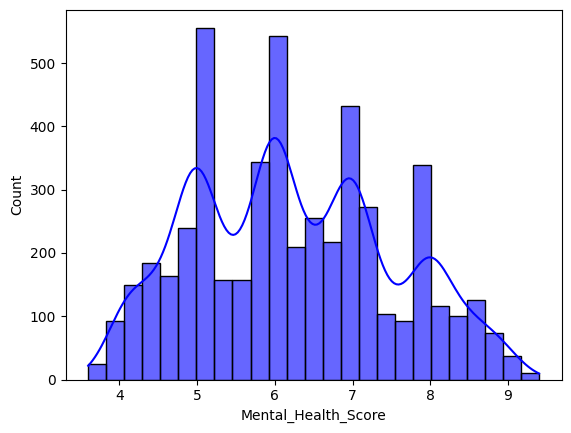

In [12]:
# target distribution
sns.histplot(df['Mental_Health_Score'], color = 'blue', kde = True, alpha = 0.6)

<Axes: >

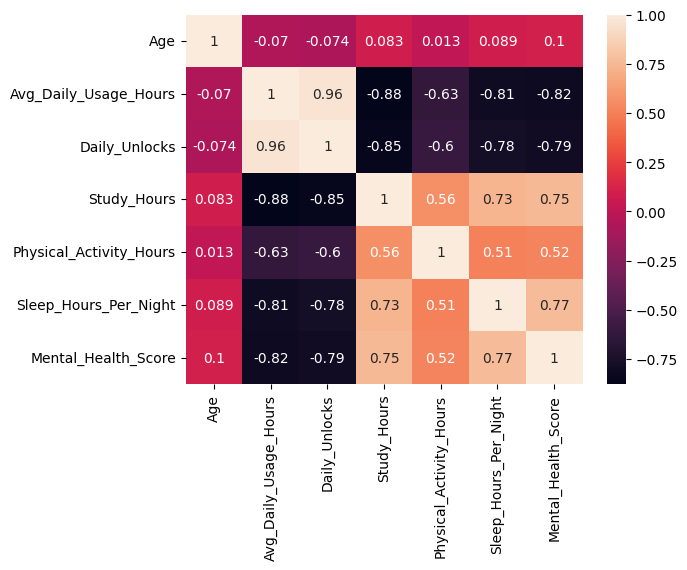

In [16]:
# correlation heatmap
sns.heatmap(df.corr(numeric_only = True).T, annot = True)

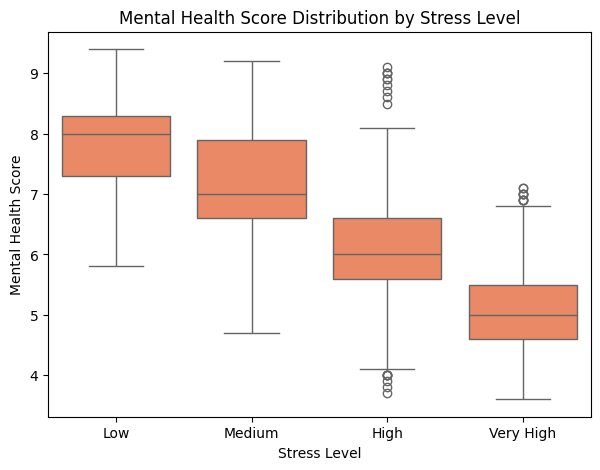

In [42]:
# stress lvl vs mental health score
plt.figure(figsize=(7,5))

order = ['Low','Medium','High','Very High']

sns.boxplot(
    x=df['Stress_Level'],
    y=df['Mental_Health_Score'],
    order = order,
    color = 'coral'
)

plt.xlabel('Stress Level')
plt.ylabel('Mental Health Score')
plt.title('Mental Health Score Distribution by Stress Level')
plt.show()

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

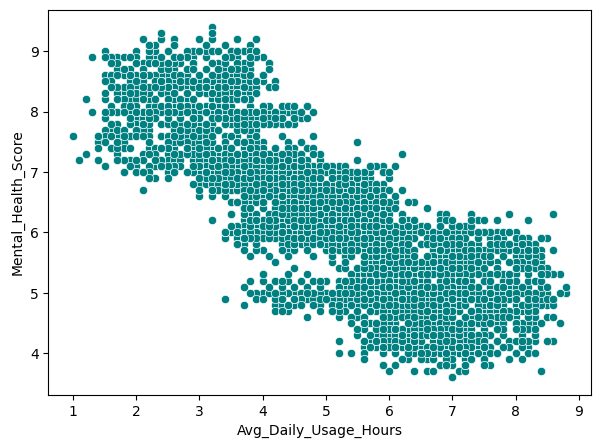

In [41]:
# daily usage hrs vs mental health score
plt.figure(figsize=(7,5))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',data=df, color = 'teal')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

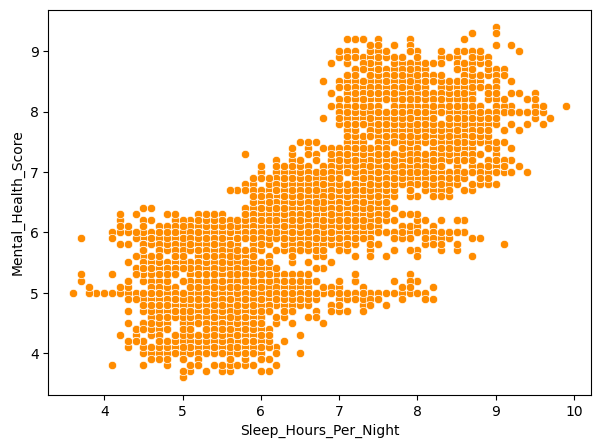

In [40]:
# sleep hours vs mental health score
plt.figure(figsize=(7,5))
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df, color = 'darkorange')

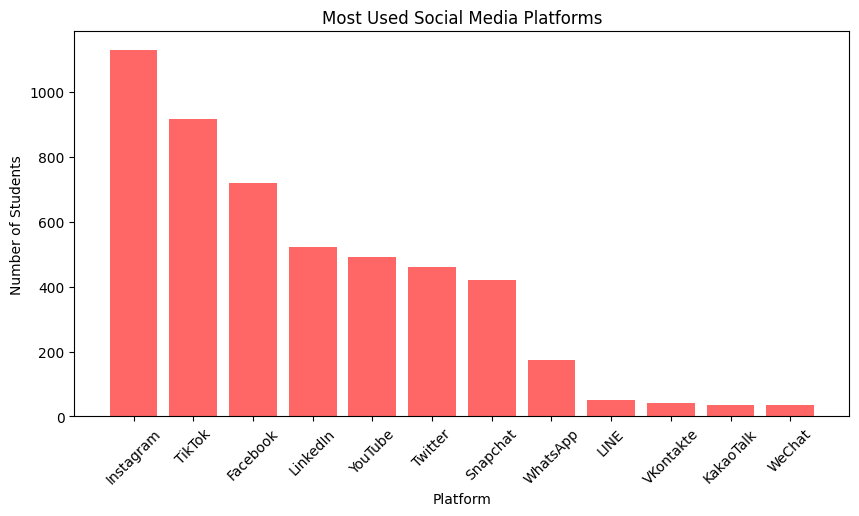

In [38]:
# most used platforms
platform_count = df['Most_Used_Platform'].value_counts()
# platform_count
plt.figure(figsize=(10,5))
plt.bar(platform_count.index, platform_count.values, color = 'red', alpha = 0.6)

plt.xlabel('Platform')
plt.ylabel('Number of Students')
plt.title('Most Used Social Media Platforms')
plt.xticks(rotation=45)

plt.show()

### **👽 Checking Outliers**

In [46]:
num_features = df.select_dtypes(include = 'number')
q1 = num_features.quantile(0.25)
q3 = num_features.quantile(0.75)
iqr = q3 - q1

In [47]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [50]:
outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


### **🧹 Data Cleaning**

In [51]:
# drop duplicates
df = df.drop_duplicates()

In [52]:
# removing -ve values from physical avtivity hrs
# replacing it with 0
# by clipping
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower = 0)

/tmp/ipykernel_1267/187834779.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower = 0)


### **📉 Data Skweness**

In [55]:
numeric_cols = df.select_dtypes(include = 'number')
numeric_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


**👉 NOTE**

- if **0** -> then **centralized**
- if **+ve** -> then **right skewed**
- if **-ve** -> then **left skewed**

### **🚀 Feature Engineering**

> One meaningful engineered feature here: grouping Country.

- Country has 111 unique values in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).

- Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.

- **The fix**: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

In [58]:
# top 10 nations
top_countries = df['Country'].value_counts().index[:10].tolist()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [60]:
# grouping nations

def grp_country(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [62]:
df['grouped_country'] = df['Country'].apply(grp_country)
df['grouped_country'].value_counts()

/tmp/ipykernel_1267/3172370583.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grouped_country'] = df['Country'].apply(grp_country)


,count
grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


### **䷖ Train test split**

In [67]:
skewed_col = ['Study_Hours'] # applying log transform
# satndard scaling
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours","Sleep_Hours_Per_Night"]
# Ordinal encoding
ordinal_col = ['Stress_Level']
# one hot ecoding
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "grouped_country"]

In [72]:
from sklearn.model_selection import train_test_split
feature_col = skewed_col + other_numeric_cols + ordinal_col + normal_col

x = df[feature_col]
y = df['Mental_Health_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

### **😶‍🌫️ Encoding and Transformation**

- **Ordinal Encoding** for `Stress_Level` as its has a natural order (low, mid, high, very high)

- **One-Hot Encoding** for `Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, `grouped_country`

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder

# skew pipeline
skew_pipeline = Pipeline(steps = [('log_transform', FunctionTransformer(np.log1p)),
                                   ('scale',StandardScaler())])
# Numeric pipeline
numeric_pipeline = Pipeline(steps = [
                  ('scale',StandardScaler())])

# ordinal pipeline
ordinal_pipeline = Pipeline(steps = [
                  ('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))])

# one hot pipeline
nominal_pipeline = Pipeline(steps = [
                   ('encode',OneHotEncoder(handle_unknown = 'ignore'))])

### **🛠️ Preprocessing Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers = [
    ('Skewed Pipeline',skew_pipeline, skewed_col),
    ('Plain Numeric',numeric_pipeline, other_numeric_cols),
    ('Ordinal Pipeline',ordinal_pipeline, ordinal_col),
    ('Nominal Pipeline',nominal_pipeline, normal_col)
])

preprocessor

ColumnTransformer(transformers=[('Skewed Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Plain Numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal Pipeline',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Nominal Pipeline',
                                 Pipeline(steps=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'grouped_country'])])

### **🥊 Model Comparison**

- Linear Regression
- RandomForest (default)
- RandomForest (Hyperparameter Tuning)

> Linear Regression

In [84]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('regressor',LinearRegression())
    ])

lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
lr_pred_train = lr.predict(x_train)

# evaluation
print('R2 score testing :',r2_score(y_test, lr_pred))
print('R2 score training :',r2_score(y_train, lr_pred_train))

R2 score testing : 0.7397944617433021
R2 score training : 0.7236771199387538


> Random Forest (default)

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf_pred_train = rf.predict(x_train)

# evaluation
print('R2 score testing :',r2_score(y_test, rf_pred))
print('R2 score training :',r2_score(y_train, rf_pred_train))

R2 score testing : 0.8775888638668996
R2 score training : 0.9808287942404612


> Random Forest (hyperparameter tuning)

In [86]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(x_train, y_train)

print(random_search.best_params_)

rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(x_test)
print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")

{'random forest__n_estimators': 200, 'random forest__min_samples_split': 5, 'random forest__min_samples_leaf': 2, 'random forest__max_depth': 15}
R2 Score for random forest after hyperparameter tuning 0.8650140569761653


> Best Model is **Random Forest(default)** ✅

### **⚡️ Save Model**

In [87]:

import joblib
joblib.dump(rf, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']